In [4]:
from utils import variables, functions

# realod them (maybe have been updated)
import importlib
importlib.reload(functions)
importlib.reload(variables)

import numpy as np, os, json, pandas as pd, random, pip
from IPython.display import clear_output
import pickle

# Matplotlib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches

# Nilearn
import nilearn
from nilearn import image as nimg
from nilearn import masking, signal, datasets, plotting
from nilearn.image import index_img
from nilearn.maskers import NiftiMasker
from nilearn.glm.first_level import FirstLevelModel

# Nibabel
from nibabel.affines import apply_affine
import nibabel as nib

Variables imported correctly.
Functions imported correctly.
Functions imported correctly.
Variables imported correctly.


#### Load data and list of the presented stimuli

In [5]:
# GET DATA

%pip install datalad
clear_output()

if not os.path.exists(variables.TMP_PATH):
    # Configure Git
    !git config --global user.name "ctomasoni5"
    !git config --global user.email "c.tomasoni5@campus.unimib.it"

    # Clone data in a temporary directory
    !datalad clone https://github.com/OpenNeuroDatasets/ds001499 /tmp/ds001499

    # Get events and confounds files
    %cd /tmp/ds001499
    !datalad get sub-*/ses-*/func/sub-*_ses-*_task-*_events.tsv

    %cd /tmp/ds001499/derivatives/fmriprep
    !datalad get sub-*/ses-*/func/sub-*_task-*_confounds.tsv

    clear_output()

    print('Dataset cloned.')
else:
    print('Folder already existing.')

# Check the folder with data
!ls -la /tmp/ds001499

Folder already existing.


total 76
drwxr-xr-x  9 mambauser mambauser 4096 Dec 23 09:16 .
drwxrwxrwt  1 root      root      4096 Jan  4 10:55 ..
-rw-r--r--  1 mambauser mambauser   14 Dec 23 09:16 .bidsignore
drwxr-xr-x  2 mambauser mambauser 4096 Dec 23 09:16 .datalad
drwxr-xr-x  9 mambauser mambauser 4096 Dec 23 09:16 .git
-rw-r--r--  1 mambauser mambauser  284 Dec 23 09:16 .gitattributes
-rw-r--r--  1 mambauser mambauser   44 Dec 23 09:16 CHANGES
-rw-r--r--  1 mambauser mambauser 2833 Dec 23 09:16 README
-rw-r--r--  1 mambauser mambauser 1227 Dec 23 09:16 dataset_description.json
drwxr-xr-x  6 mambauser mambauser 4096 Dec 23 09:16 derivatives
-rw-r--r--  1 mambauser mambauser  119 Dec 23 09:16 participants.tsv
drwxr-xr-x 18 mambauser mambauser 4096 Dec 23 09:16 sub-CSI1
drwxr-xr-x 18 mambauser mambauser 4096 Dec 23 09:16 sub-CSI2
drwxr-xr-x 18 mambauser mambauser 4096 Dec 23 09:16 sub-CSI3
drwxr-xr-x 12 mambauser mambauser 4096 Dec 23 09:16 sub-CSI4
-rw-r--r--  1 mambauser mambauser  131 Dec 23 09:16 task-500

In [ ]:
#!pip install bids

In [ ]:
import bids
from bids import BIDSLayout
TMP_PATH = '/tmp/ds001499'

if not os.path.exists(os.path.join(variables.BOLD5000_PATH,'all_sessions.json')):

  layout = BIDSLayout(os.path.join(TMP_PATH,'derivatives/fmriprep'), validate=False, config=['bids','derivatives']) 

  subjects = ['CSI1','CSI2','CSI3','CSI4']

  sessions_with_localizer = {sub: [] for sub in subjects}
  all_sessions = {sub: [] for sub in subjects}

  for sub in subjects:
      subject_path = os.path.join(os.path.join(variables.TMP_PATH,'derivatives/fmriprep'), 'sub-'+sub)
      if not os.path.isdir(subject_path):
          print(f"Warning: Subject directory not found: {subject_path}")
          continue

      for ses_dir in sorted(os.listdir(subject_path)):
          if not ses_dir.startswith('ses-'):
              continue
          all_sessions[sub].append(ses_dir)

          ses_path = os.path.join(subject_path, ses_dir)
          func_dir = os.path.join(ses_path, 'func')
          if not os.path.isdir(func_dir):
              continue

          event_files = layout.get(
              subject=sub,
              session=ses_dir.replace('ses-', ''), # Extract session number
              task='localizer', # Filter for localizer task
              return_type='file'
          )
          if event_files:
              sessions_with_localizer[sub].append(ses_dir)

  %cd /workspace/devcontainer-bigdata/data
  # save the dict
  with open('sessions_with_localizer.json', 'w') as f:
        json.dump(sessions_with_localizer, f)

  # save the dict
  with open('all_sessions.json', 'w') as f:
        json.dump(all_sessions, f)
  
  print(f'Files created and saved.\n')
    
else:
      %cd /workspace/devcontainer-bigdata/data

      # Load sessions with localizer
      with open('sessions_with_localizer.json', 'r') as f:
            sessions_with_localizer = json.load(f)

      # Load all sessions
      with open('all_sessions.json', 'r') as f:
            all_sessions = json.load(f)
      
      print(f'Files loaded.\n')


# Print the sessions with localizer for each subject
for sub, sessions in sessions_with_localizer.items():
      print(f"Subject {sub}: Sessions with localizer task: {sessions}")
print('\n')
for sub, sessions in all_sessions.items():
    print(f"Subject {sub}: Total sessions: {sessions}")

/workspace/devcontainer-bigdata/data
Files loaded.

Subject CSI1: Sessions with localizer task: ['ses-04', 'ses-06', 'ses-08', 'ses-09', 'ses-11', 'ses-12', 'ses-13', 'ses-14']
Subject CSI2: Sessions with localizer task: ['ses-02', 'ses-06', 'ses-07', 'ses-08', 'ses-09', 'ses-10', 'ses-13', 'ses-15']
Subject CSI3: Sessions with localizer task: ['ses-02', 'ses-04', 'ses-08', 'ses-09', 'ses-10', 'ses-12', 'ses-13', 'ses-14']
Subject CSI4: Sessions with localizer task: ['ses-02', 'ses-03', 'ses-05', 'ses-06', 'ses-07', 'ses-08']


Subject CSI1: Total sessions: ['ses-01', 'ses-02', 'ses-03', 'ses-04', 'ses-05', 'ses-06', 'ses-07', 'ses-08', 'ses-09', 'ses-10', 'ses-11', 'ses-12', 'ses-13', 'ses-14', 'ses-15', 'ses-16']
Subject CSI2: Total sessions: ['ses-01', 'ses-02', 'ses-03', 'ses-04', 'ses-05', 'ses-06', 'ses-07', 'ses-08', 'ses-09', 'ses-10', 'ses-11', 'ses-12', 'ses-13', 'ses-14', 'ses-15', 'ses-16']
Subject CSI3: Total sessions: ['ses-01', 'ses-02', 'ses-03', 'ses-04', 'ses-05', 'se

In [7]:
# Create a df with all the runs
if True:         # SET TO TRUE IF YOU WANT TO CONSIDER ALL THE SESSIONS
  # dataframe
  stim_pres_path = os.path.join(variables.BOLD5000_PATH,'Stimuli_Presentation_Lists')
  stimuli_presentation_df = pd.DataFrame(columns=['subject','session','run','stimuli_presentation_list','path'])
  for sub in sorted(os.listdir(stim_pres_path)):
    #print(sub)
    for ses in sorted(os.listdir(os.path.join(stim_pres_path,sub))):
      # if session is in sessions_with_localizers
      if str(ses[-2:]) in [number[-2:] for number in all_sessions[sub]]:      # ALL SESSIONS
        #print(f'Session {ses} has localizer')
        runs = sorted(os.listdir(os.path.join(stim_pres_path,sub,ses)))
        for run in runs:
          if run.endswith('.txt'):                  # there are two files (one .txt and one .mat for each run)
            number_run=run.split('.')[-2][-2:]
            path = os.path.join(stim_pres_path,sub,ses,run)
            stimuli_presentation_df.loc[len(stimuli_presentation_df)] = [sub, ses[-2:], number_run, run, path]
  del stim_pres_path

  print(f'Length of the dataframe: {len(stimuli_presentation_df)}')

Length of the dataframe: 510


In [8]:
stimuli_presentation_df.head(3)

,subject,session,run,stimuli_presentation_list,path
0,CSI1,01,01,CSI_sess01_run01.txt,/workspace/devcontainer-bigdata/data/Stimuli_P...
1,CSI1,01,02,CSI_sess01_run02.txt,/workspace/devcontainer-bigdata/data/Stimuli_P...
2,CSI1,01,03,CSI_sess01_run03.txt,/workspace/devcontainer-bigdata/data/Stimuli_P...


In [9]:
n_sessions_localizer = 0
for i in sessions_with_localizer:
  n_sessions_localizer += len(sessions_with_localizer[i])

n_all_sessions = 0
for i in all_sessions:
  n_all_sessions += len(all_sessions[i])

print(f'Number of total sessions: {n_all_sessions}')
print(f'Number of sessions with localizer task: {n_sessions_localizer}')

Number of total sessions: 58
Number of sessions with localizer task: 30


In [10]:
if not os.path.exists(os.path.join(variables.BOLD5000_PATH,'all_stimuli.txt')):
  all_stimuli = []
  # open all the stimuli_presentation_df['path'][i] and add the content to a list
  for i in range(len(stimuli_presentation_df)):
    with open(stimuli_presentation_df['path'][i]) as file:
      stimuli_list = [line.strip() for line in file]
      all_stimuli += stimuli_list
  print(f"Number of presented stimuli to all subjects: {len(all_stimuli)}")

  # save all_stimuli on drive
  with open(os.path.join(variables.BOLD5000_PATH,'all_stimuli.txt'), 'w') as f:
      for item in all_stimuli:
          f.write("%s\n" % item)
else:
  # load all_stimuli list
  with open(os.path.join(variables.BOLD5000_PATH,'all_stimuli.txt'), 'r') as f:
      all_stimuli = [line.strip() for line in f]

  print(f"Number of presented stimuli to all subjects: {len(all_stimuli)}")

Number of presented stimuli to all subjects: 18870


#### EVENTS

Idea: select only the stimuli that refer to SUN or ImageNet datasets.

To do:
- take the dataframes created before (in language_models.ipynb) and define a function final_mapping() to map each ImageNet and SUN label to one of the final labels.
- create a final df with three columns: img_name, original_label, final_label. It has to have the length of all_stimuli
- open the events and filter the data taking only stimuli from ImageNet and SUN

In [11]:
complete_final_df = pd.read_csv(os.path.join(variables.BOLD5000_PATH,'complete_final_df.csv'))
complete_final_df.sample(5)

,original_name,label
569,n03584254,object
506,n03240683,object
180,n02099712,animal or human
456,n03000247,object
258,n02125311,animal or human


In [12]:
events_df = pd.DataFrame(columns=['subject','session','run','events','path'])

for sub in sorted(os.listdir(variables.TMP_PATH)):
    if sub.split('-')[-1] in all_sessions:

        for ses in sorted(os.listdir(os.path.join(variables.TMP_PATH, sub))):
            if str(ses[-2:]) in [number[-2:] for number in all_sessions[sub.split('-')[-1]]]:

                if not os.path.isdir(os.path.join(variables.TMP_PATH, sub, ses, 'func')):
                    continue

                for el in sorted(os.listdir(os.path.join(variables.TMP_PATH, sub, ses, 'func'))):
                    if 'task-5000scenes' in el and 'events.tsv' in el:
                        run = el.split('-')[-1].split('_')[0]
                        task_file = el                     
                        
                        path = os.path.join(variables.TMP_PATH, sub, ses, 'func', el)   

                        events_df.loc[len(events_df)] = [sub, ses[-2:], run, task_file, path]

                # UNCOMMENT THIS IF YOU WANT TO INCLUDE ALSO THE LOCALIZER RUNS.
                # I DON'T NEED THEM FOR THE CLASSIFICAZION TASK SINCE THEY USE DIFFERENTI STIMULI
                
                # add the localizer if it ecists
                #localizer_file = f'{sub}_{ses}_task-localizer_events.tsv'
                #localizer_path = os.path.join(variables.TMP_PATH, sub, ses, 'func', localizer_file)
                #if os.path.exists(localizer_path):
                #    events_df.loc[len(events_df)] = [sub, ses[-2:], 'localizer', localizer_file, localizer_path]

In [13]:
events_df.head(3)

,subject,session,run,events,path
0,sub-CSI1,01,01,sub-CSI1_ses-01_task-5000scenes_run-01_events.tsv,/tmp/ds001499/sub-CSI1/ses-01/func/sub-CSI1_se...
1,sub-CSI1,01,02,sub-CSI1_ses-01_task-5000scenes_run-02_events.tsv,/tmp/ds001499/sub-CSI1/ses-01/func/sub-CSI1_se...
2,sub-CSI1,01,03,sub-CSI1_ses-01_task-5000scenes_run-03_events.tsv,/tmp/ds001499/sub-CSI1/ses-01/func/sub-CSI1_se...


In [14]:
# open events_df[0]
event = pd.read_csv(events_df['path'][39], sep='\t')
event.head(5)

,onset,duration,Subj,Sess,Run,Trial,ImgName,ImgType,StimOn(s),StimOff(s),Response,RT,stim_file
0,6.0377,0.9679,1,5,1,1,n02403003_10578.JPEG,imagenet,6.0377,7.0055,1,4.3107,n02403003_10578.JPEG
1,16.0129,0.9839,1,5,1,2,n07753113_34311.JPEG,imagenet,16.0129,16.9968,2,2.3081,n07753113_34311.JPEG
2,26.0046,1.0008,1,5,1,3,n02033041_3885.JPEG,imagenet,26.0046,27.0054,1,2.3919,n02033041_3885.JPEG
3,35.9960,1.0011,1,5,1,4,COCO_train2014_000000216539.jpg,coco,35.9960,36.9972,1,2.1041,COCO_train2014_000000216539.jpg
4,46.0047,1.0008,1,5,1,5,COCO_train2014_000000565857.jpg,coco,46.0047,47.0056,3,3.9522,COCO_train2014_000000565857.jpg


In [15]:
# Open all rows of events_df (columnn 'path'), to open the event dataframe of each run, which is composed of 37 trials (37 stimuli presented)
# Read the column 'stim_file' for each run, and add all the images names to a list, and check if it is eqaul to all_stimuli

all_stimuli_from_events = []

for row in range(len(events_df)):
    event = pd.read_csv(events_df['path'][row], sep='\t')       # event is a df
    for ev_row in range(len(event)):
        all_stimuli_from_events.append(event['stim_file'][ev_row])

In [16]:
# Check if they are the same
if sorted(all_stimuli_from_events)!=sorted(all_stimuli):
    print('Something wrong. NOT SAME LIST OF STIMULI\n') 

print(f'First 10 elements in all_stimuli and NOT in all_stimuli_from_events: {list(set(all_stimuli) - set(all_stimuli_from_events))[:10]}')

print(f'First 10 elements in all_stimuli_from_events and NOT in all_stimuli: {list(set(all_stimuli_from_events) - set(all_stimuli))[:10]}')

Something wrong. NOT SAME LIST OF STIMULI

First 10 elements in all_stimuli and NOT in all_stimuli_from_events: ['rep_n04026417_26908.JPEG', 'rep_n01798484_1157.JPEG', 'rep_COCO_train2014_000000399337.jpg', 'rep_campsite3.jpg', 'rep_beach3.jpg', 'rep_COCO_train2014_000000470999.jpg', 'rep_COCO_train2014_000000470907.jpg', 'rep_recordingstudio1.jpg', 'rep_n04465501_9230.JPEG', 'rep_COCO_train2014_000000450864.jpg']
First 10 elements in all_stimuli_from_events and NOT in all_stimuli: []


The lists should be equal but they are different.

In [17]:
# Seems like the problem is that all_stimuli contains the images presented more than once with the prefix 'rep_'
# check if this is the only problem
for i in range(len(list(set(all_stimuli) - set(all_stimuli_from_events)))):
    assert 'rep_' in list(set(all_stimuli) - set(all_stimuli_from_events))[i]

In [18]:
# Check if in Scene_Stimuli there are both the names
img_rep = 'rep_COCO_train2014_000000535994.jpg'
img = img_rep[4:]

if os.path.exists(os.path.join(variables.BOLD5000_PATH,'Scene_Stimuli','Presented_Stimuli','COCO',img)):
    print(f'Path: {img} exists.')
else:
    print(f'Path: {img} DOES NOT exist.')
 
if os.path.exists(os.path.join(variables.BOLD5000_PATH,'Scene_Stimuli','Presented_Stimuli','COCO',img_rep)):
    print(f'Path: {img_rep} exists.')   
else:
    print(f'Path: {img_rep} DOES NOT exist.') 

Path: COCO_train2014_000000535994.jpg exists.
Path: rep_COCO_train2014_000000535994.jpg DOES NOT exist.


Means that the prefix 'rep_' is added only in the folder Stimuli_Presentation_Lists

In [19]:
# Check if removing 'rep_' from all the image names, the two lists are equal
all_stimuli_temp=[]
for i in range(len(all_stimuli)):
    if 'rep_' in all_stimuli[i]:
        all_stimuli_temp.append(all_stimuli[i][4:])
    else:
        all_stimuli_temp.append(all_stimuli[i])
if sorted(all_stimuli_temp)==sorted(all_stimuli):
    print(f'Okay. now they are equal.')
else:
    print('STILL NOT EQUAL.')

STILL NOT EQUAL.


In [20]:
# Maybe it's a problem of format or spaces 
list1 = all_stimuli_temp
list2 = all_stimuli_from_events

norm1 = [str(x).strip() for x in list1]
norm2 = [str(x).strip() for x in list2]

sorted1 = sorted(norm1)
sorted2 = sorted(norm2)
sorted1 == sorted2

True

Ok. Now I have to define a function which maps the image name to the final category.
But first, I'll extract the list of stimuli only with ImageNet and SUN, and ignore the COCO images.

In [21]:
# Create a final list of stimuli ignoring COCO
all_stimuli_final = []
for i in range(len(all_stimuli_temp)):
    if 'COCO' in all_stimuli_temp[i]:
        continue
    all_stimuli_final.append(all_stimuli_temp[i])
print(len(all_stimuli_final))

11193


In [22]:
mapping_df = pd.DataFrame(columns=['image_name','label'])
mapping_df['image_name'] = all_stimuli_final
mapping_df['label'] = mapping_df['image_name'].apply(lambda x: functions.mapping_image_to_label(x, complete_final_df))

# dimensions
print(f'Number of rows: {len(mapping_df)}')
print(f'Number of columns: {len(mapping_df.columns)}')
mapping_df.head(5)

Number of rows: 11193
Number of columns: 2


,image_name,label
0,n01930112_19568.JPEG,animal or human
1,n03733281_29214.JPEG,object
2,n07695742_5848.JPEG,plant or food
3,n01917289_1429.JPEG,animal or human
4,n02108551_26574.JPEG,animal or human


In [23]:
assert len(all_stimuli_final) == len(mapping_df)

mapping_df.isna().sum()

image_name    0
label         0
dtype: int64

Let's Goooo! There are no NaNs. 
Each image name has been mapped to one of the final_categories.

To do:
- open the events and filter the data taking only stimuli from ImageNet and SUN.

In [24]:
labels_dist = complete_final_df['label'].value_counts()

Final categories: ['object', 'animal or human', 'plant or food', 'scene']


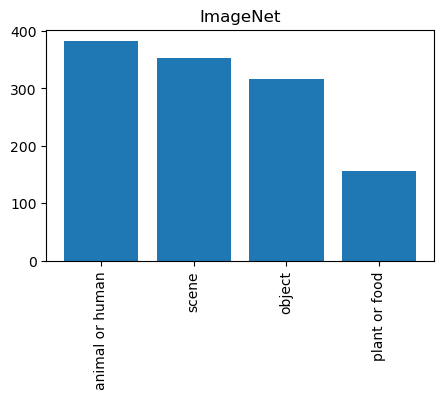

In [25]:
# Distribution of the stimuli presented across the different labels
print(f"Final categories: {variables.FINAL_CATEGORIES}")

labels_dist = complete_final_df['label'].value_counts()

plt.figure(figsize=(5,3))
plt.bar(labels_dist.index, labels_dist.values)
plt.title('ImageNet')
plt.xticks(rotation=90)
plt.show()

#### Confounds

Explanation
- dataframes in confounds contain movement regressors (trans_x, rot_x, trans_y, ...) and noise signals (CSF, white_matter, a_comp_cor, ...)
- these data can be applied to the registered neural responses, to clean the data, removing artifacts and physiological components which we are not interested in

In [26]:
confounds_df = pd.DataFrame(columns=['subject','session','run','confounds','path'])

for sub in sorted(os.listdir(os.path.join(variables.TMP_PATH,'derivatives','fmriprep'))):
    if sub.split('-')[-1] in all_sessions:

        for ses in sorted(os.listdir(os.path.join(variables.TMP_PATH,'derivatives','fmriprep',sub))):
            if str(ses[-2:]) in [number[-2:] for number in all_sessions[sub.split('-')[-1]]]:

                if not os.path.isdir(os.path.join(variables.TMP_PATH,'derivatives','fmriprep',sub,ses,'func')):
                    continue

                for el in sorted(os.listdir(os.path.join(variables.TMP_PATH,'derivatives','fmriprep',sub,ses,'func'))):
                    if 'task-5000scenes' in el and '_bold_confounds.tsv' in el:
                        
                        run = el.split('-')[-1].split('_')[0]
                        task_file = el                 
                        task_path = os.path.join(variables.TMP_PATH,'derivatives','fmriprep',sub,ses,'func',el)    

                        confounds_df.loc[len(confounds_df)] = [sub, ses[-2:], run, task_file, task_path]

                # uncomment to add the localizer runs
                #localizer_file = f'{sub}_{ses}_task-localizer_bold_confounds.tsv'
                #localizer_path = f'{func_path}/{localizer_file}'
                #if os.path.exists(localizer_path):
                #    confounds_df.loc[len(confounds_df)] = [sub, ses[-2:], 'localizer', localizer_file, localizer_path]

In [27]:
assert len(confounds_df)==len(events_df)
confounds_df.head(3)

,subject,session,run,confounds,path
0,sub-CSI1,01,01,sub-CSI1_ses-01_task-5000scenes_run-01_bold_co...,/tmp/ds001499/derivatives/fmriprep/sub-CSI1/se...
1,sub-CSI1,01,02,sub-CSI1_ses-01_task-5000scenes_run-02_bold_co...,/tmp/ds001499/derivatives/fmriprep/sub-CSI1/se...
2,sub-CSI1,01,03,sub-CSI1_ses-01_task-5000scenes_run-03_bold_co...,/tmp/ds001499/derivatives/fmriprep/sub-CSI1/se...


In [28]:
# open first one file tsv as dataframe
(pd.read_csv(confounds_df['path'][0], sep='\t')).head(5)

,CSF,WhiteMatter,GlobalSignal,stdDVARS,non-stdDVARS,vx-wisestdDVARS,FramewiseDisplacement,tCompCor00,tCompCor01,tCompCor02,...,Cosine02,Cosine03,Cosine04,NonSteadyStateOutlier00,X,Y,Z,RotX,RotY,RotZ
0,646.635092,480.358860,496.407731,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,-0.000000,0.0
1,640.246303,479.962426,494.537749,1.574400,40.081921,1.236363,0.127343,-0.037195,0.018416,0.112920,...,0.101767,0.101743,0.101713,0.0,0.002961,0.074485,0.044360,0.000016,0.000095,0.0
2,637.320634,480.029791,493.742571,1.468624,37.389004,1.129910,0.214846,0.089922,-0.005237,0.085775,...,0.101524,0.101312,0.101040,0.0,-0.003015,-0.075093,0.029535,0.000618,-0.000192,0.0
3,638.691279,479.420751,493.244284,1.435973,36.557774,1.197999,0.192759,0.087927,0.014792,-0.123122,...,0.101040,0.100452,0.099697,0.0,-0.000004,0.071554,0.023811,-0.000091,-0.000154,0.0
4,635.160850,479.668616,492.698220,1.320796,33.625538,1.019693,0.059516,-0.026237,-0.044783,-0.092143,...,0.100314,0.099165,0.097695,0.0,0.000003,0.033982,0.027796,-0.000429,-0.000133,0.0


In [29]:
# Check the length of the file tsv for each run (for each row in confounds_df)
temp=[]
for i in range(len(confounds_df)):
    confounds = pd.read_csv(confounds_df['path'][i], sep='\t')
    temp.append(len(confounds))
if len(np.unique(temp))==1:     # if all the events have same length
    print(f'The number of stimuli presented in each run of confounds is: {len(confounds)}')
else:
    print('ERROR\nThe number of stimuli presented in a run is NOT the same for all the runs.')

The number of stimuli presented in each run of confounds is: 194


To do: check that the functional file, the BOLD file (.nii.gz file) has 194 volumes.

#### Anatomical data

In [27]:
# Get the anatomical data from Open Neuro
!aws s3 sync \
    s3://openneuro.org/ds001499/derivatives/fmriprep/ \
    /tmp/ds001499/derivatives/fmriprep \
    --no-sign-request \
    --exact-timestamps \
    --exclude "*" \
    --include "sub-CSI*/anat/*_brainmask.nii.gz" \

clear_output()

In [28]:
# Create df
anatomicals_df = pd.DataFrame(columns=['subject',  'filename', 'path'])

for sub in sorted(os.listdir(os.path.join(variables.TMP_PATH,'derivatives','fmriprep'))):
    
    # enter in the 'anat' folder of each subject
    if not os.path.isdir(os.path.join(variables.TMP_PATH,'derivatives','fmriprep',sub,'anat')):
        continue

    # For each session
    for el in sorted(os.listdir(os.path.join(variables.TMP_PATH,'derivatives','fmriprep',sub,'anat'))):

            if el.endswith('brainmask.nii.gz'):

                sub = el.split('_')[0]
                path = os.path.join(variables.TMP_PATH,'derivatives','fmriprep',sub,'anat',el)

                anatomicals_df.loc[len(anatomicals_df)] = [sub, el, path]

# Order for subject and for session
anatomicals_df = anatomicals_df.sort_values(['subject']).reset_index(drop=True)

In [29]:
anatomicals_df

,subject,filename,path
0,sub-CSI1,sub-CSI1_T1w_brainmask.nii.gz,/tmp/ds001499/derivatives/fmriprep/sub-CSI1/an...
1,sub-CSI2,sub-CSI2_T1w_brainmask.nii.gz,/tmp/ds001499/derivatives/fmriprep/sub-CSI2/an...
2,sub-CSI3,sub-CSI3_T1w_brainmask.nii.gz,/tmp/ds001499/derivatives/fmriprep/sub-CSI3/an...
3,sub-CSI4,sub-CSI4_T1w_brainmask.nii.gz,/tmp/ds001499/derivatives/fmriprep/sub-CSI4/an...


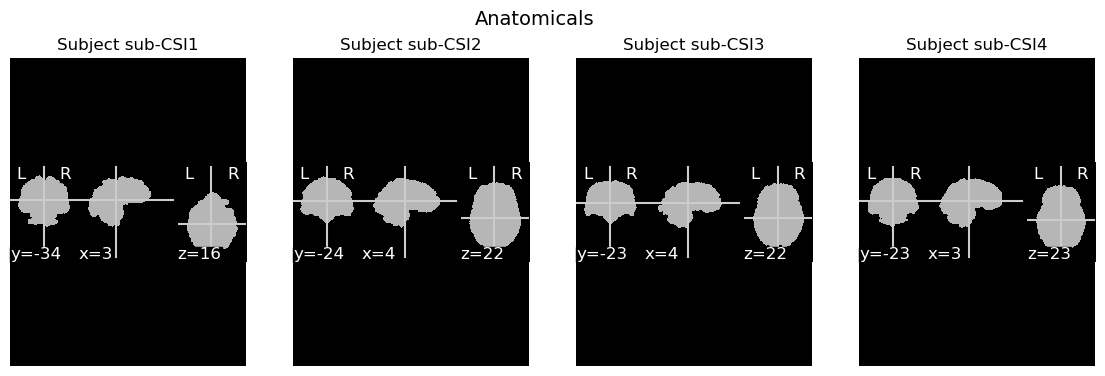

In [30]:
# Nilearn plot_anat function plots cuts of an anatomical image
# the 3 default cuts that are plotted are: Frontal, Axial, Lateral

fig, axs = plt.subplots(1, 4, figsize=(14,4))
axes = axs.flatten()
fig.suptitle('Anatomicals', fontsize=14, y=1)
for i in range(len(anatomicals_df)):
  img = nib.load(anatomicals_df['path'][i])
  nilearn.plotting.plot_anat(img, axes=axes[i], colorbar=False)
  axes[i].set_title(f'Subject {anatomicals_df['subject'][i]}')
plt.show()

#### ROIs

References:

https://andysbrainbook.readthedocs.io/en/latest/SPM/SPM_Short_Course/SPM_09_ROIAnalysis.html

https://www.nature.com/articles/s41597-019-0052-3

https://www.nitrc.org/projects/funroi/

In [30]:
# if the rois dataframe has not been created yet, get the data from Open Neuro
if True:
    !aws s3 sync \
    s3://openneuro.org/ds001499/derivatives/spm/ \
    /tmp/ds001499/derivatives/spm \
    --no-sign-request \
    --exact-timestamps \
    --exclude "*" \
    --include "sub-CSI*/*_mask-*.nii.gz" \

clear_output()

In [31]:
if not os.path.exists(os.path.join(variables.BOLD5000_PATH,'rois_df.csv')):
    # Create df
    rois_df = pd.DataFrame(columns=['subject', 'roi', 'hemisphere', 'filename', 'path'])

    # For each subject
    for sub in sorted(os.listdir(os.path.join(variables.TMP_PATH,'derivatives','spm'))):
        
        if not os.path.isdir(os.path.join(variables.TMP_PATH,'derivatives','spm',sub)):
            continue

        # For each session
        for roi in sorted(os.listdir(os.path.join(variables.TMP_PATH,'derivatives','spm',sub))):

                if roi.endswith('.nii.gz'):

                    sub = roi.split('_')[0]
                    roi_name = roi.split('.')[-3].split('-')[-1]
                    hemisphere = 'left' if 'LH' in roi else 'right'

                    rois_df.loc[len(rois_df)] = [
                        sub, roi_name, hemisphere, roi, os.path.join(variables.TMP_PATH,'derivatives','spm',sub,roi)]

    # Order for subject and session
    rois_df = rois_df.sort_values(['subject']).reset_index(drop=True)

    # Save it
    rois_df.to_csv(os.path.join(variables.BOLD5000_PATH,'rois_df.csv'), index=False)
else:
    rois_df = pd.read_csv(os.path.join(variables.BOLD5000_PATH,'rois_df.csv'))

In [32]:
rois_df.head(3)

,subject,roi,hemisphere,filename,path,voxels_active
0,sub-CSI1,LHEarlyVis,left,sub-CSI1_mask-LHEarlyVis.nii.gz,/tmp/ds001499/derivatives/spm/sub-CSI1/sub-CSI...,210
1,sub-CSI1,LHLOC,left,sub-CSI1_mask-LHLOC.nii.gz,/tmp/ds001499/derivatives/spm/sub-CSI1/sub-CSI...,152
2,sub-CSI1,LHOPA,left,sub-CSI1_mask-LHOPA.nii.gz,/tmp/ds001499/derivatives/spm/sub-CSI1/sub-CSI...,101


Description of ROIs
- PPA: parahippocampal place area. PPA is defined as a region in the brain associated with the processing of spatial layouts and navigation, particularly important for recognizing and describing environments.
- RSC: retrospleanial complex.  RSC is defined as a core region of the default mode network (DMN) that is associated with episodic memory retrieval and is involved in mind wandering and spontaneous thought processes.
- OPA: occipital place area.

PPA, RSC, OPA are all "scene-selective" regions of interest. They were defined using the contrast of scenes compared with objects and scrambled.

- LOC: lateral occipital complex. It is an object selective area. Defined by comparing objects to scrambled images.

- EV: early visual roi. Defined by comparing the scrambled images to baseline. (Areas V1, V2, and sometimes it extends a bit beyond).

#### BOLD

In [34]:
# if the dataframe is not created yet download the functional data of all subjects and all sessions
# if not os.path.exists(os.path.join(variables.BOLD5000_PATH,'functionals_df.csv')):
if True:
  !aws s3 sync \
    s3://openneuro.org/ds001499/derivatives/fmriprep/ \
    /tmp/ds001499/derivatives/fmriprep \
    --no-sign-request \
    --exact-timestamps \
    --exclude "*" \
    --include "sub-CSI3/*/func/*_space-T1w_preproc.nii.gz" \

clear_output()

In [35]:
if not os.path.exists(os.path.join(variables.BOLD5000_PATH,'functionals_df.csv')):
    # Create df
    functionals_df = pd.DataFrame(columns=['subject', 'session', 'run', 'filename', 'path'])

    # Scansiona tutti i soggetti
    for sub in sorted(os.listdir(os.path.join(variables.TMP_PATH,'derivatives','fmriprep'))):
        
        if not os.path.isdir(os.path.join(variables.TMP_PATH,'derivatives','fmriprep',sub)):
            continue

        # For each session
        for ses in sorted(os.listdir(os.path.join(variables.TMP_PATH,'derivatives','fmriprep',sub))):
        
            if not os.path.exists(os.path.join(variables.TMP_PATH,'derivatives','fmriprep',sub,ses,'func')):
                continue

            # Scan each file
            for f in os.listdir(os.path.join(variables.TMP_PATH,'derivatives','fmriprep',sub,ses,'func')):
                if f.endswith('_space-T1w_preproc.nii.gz'):
                    
                    # Exclude the localizers
                    run = 'localizer' if 'localizer' in f else f.split('_run-')[1].split('_')[0]
                    ses = f.split('_')[1]       # take 'ses-01'

                    if run!='localizer':
                        functionals_df.loc[len(functionals_df)] = [
                            sub,
                            ses,
                            run,
                            f,
                            os.path.join(variables.TMP_PATH,'derivatives','fmriprep',sub,ses,'func',f)
                        ]

    # Order by subject and session
    functionals_df = functionals_df.sort_values(['subject','session','run']).reset_index(drop=True)

    # Save
    functionals_df.to_csv(os.path.join(variables.BOLD5000_PATH,'functionals_df.csv'), index=False)
else:
    functionals_df = pd.read_csv(os.path.join(variables.BOLD5000_PATH,'functionals_df.csv'))
functionals_df.head(2)

,subject,session,run,filename,path
0,sub-CSI1,ses-01,1,sub-CSI1_ses-01_task-5000scenes_run-01_bold_sp...,/tmp/ds001499/derivatives/fmriprep/sub-CSI1/se...
1,sub-CSI1,ses-01,2,sub-CSI1_ses-01_task-5000scenes_run-02_bold_sp...,/tmp/ds001499/derivatives/fmriprep/sub-CSI1/se...


In [36]:
# open the first existing file in functionals_df
for i in range(len(functionals_df)):
  functionals_path = functionals_df['path'][i]
  if os.path.exists(functionals_path):
    img = nib.load(functionals_path)       # nibabel object
    data = img.get_fdata()                 # numpy array: shape (X, Y, Z, T)
    print("Shape fMRI:", data.shape)
    break
  else:
    continue

Shape fMRI: (71, 89, 72, 194)


The NifTi format essentially stores the images as multi-dimensional arrays, including specific header/metadata information interpreted by Nilearn and Nibabel.

https://medium.com/@visweshkris/sleep-deprivation-classification-using-bold-fmri-data-9cb762720131

L'asse z corrisponde alla direzione cranio-caudale, dal basso verso l'alto del cervello.

lower z --> slice more at the bottom (vicino al cervelletto)

higher z --> slice more at the top (near the superior cortex)

In [37]:
from matplotlib.gridspec import GridSpec

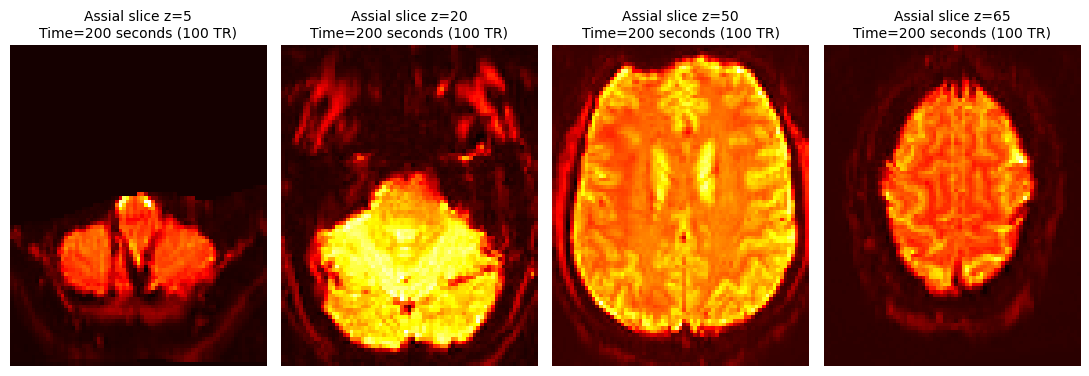

In [85]:
# Comparison between activation maps at different heights of the brain
# Activation map 
x, y, z, t = data.shape

# different heights where to cut the brain image
slices=[5, 20, 50, 65]

# select an instant (first one) --> the yth TR
# Each TR is 2 seconds. Meaning that y TR = 20 seconds
timepoint = 100

fig, axes = plt.subplots(1,4,figsize=(11,4))
axes = axes.flatten()

for i, slice_z in enumerate(slices):
    # extract the 2d slice
    slice_data = data[:, :, slice_z, timepoint]
    im = axes[i].imshow(slice_data.T, cmap="hot", origin="lower")
    axes[i].set_title(f"Assial slice z={slice_z}\nTime={timepoint*2} seconds ({timepoint} TR)", fontsize=10)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

Un singolo volume fMRI (.nii.gz) contiene intensità di segnale grezzo (valori di BOLD), non mappe di attivazione già elaborate. Per questo, se plotti una slice di un timepoint, sembra “uniformemente attivata”: in realtà stai solo vedendo il livello di intensità del segnale, che varia poco tra voxel.

I dati fMRI grezzi hanno valori simili in tutto il cervello (rumore + segnale di base).

Le “mappe di attivazione” che si vedono negli articoli scientifici derivano da analisi statistiche (GLM, contrasto, regressione sul design sperimentale).

Senza preprocessing (normalizzazione, smoothing, regressione del design), non si vedono differenze nette.

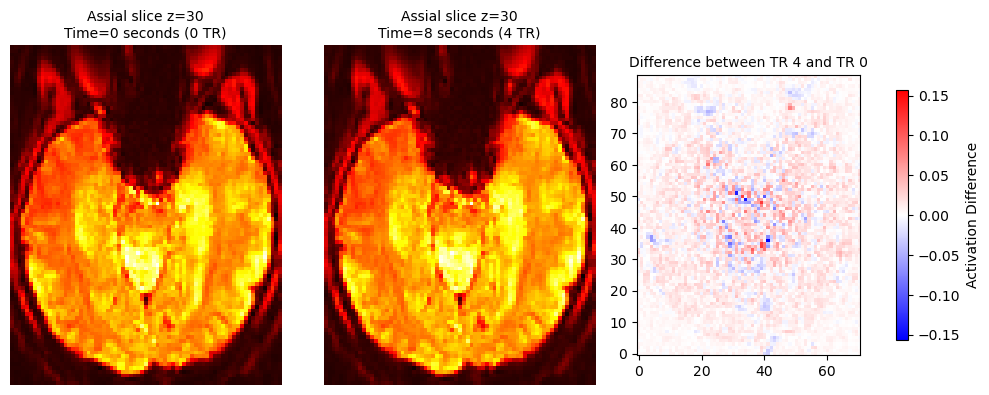

In [86]:
# Comparison between slices at different timepoints
x, y, z, t = data.shape

# different heights where to cut the brain image
slice_z = 30

timepoints = [0,4]

fig, axes = plt.subplots(1,3,figsize=(10,4))
axes = axes.flatten()
ims = []
for i, time in enumerate(timepoints):
    # extract the 2d slice
    slice_data = data[:, :, slice_z, time]
    # normalize
    slice_norm = (slice_data - slice_data.min()) / (slice_data.max() - slice_data.min())
    im = axes[i].imshow(slice_norm.T, cmap="hot", origin="lower")
    axes[i].set_title(f"Assial slice z={slice_z}\nTime={time*2} seconds ({time} TR)", fontsize=10)
    axes[i].axis("off")
    ims.append(slice_norm)
diff = ims[1]-ims[0]
vmax = np.abs(diff).max()
im2 = axes[2].imshow((ims[1]-ims[0]).T, cmap="bwr", origin="lower", vmin=-vmax, vmax=vmax)
axes[2].set_title(f"Difference between TR {timepoints[1]} and TR {timepoints[0]}", fontsize=10)
cbar = fig.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.13)
cbar.set_label("Activation Difference")

axes[i].axis("off")

plt.tight_layout()
plt.show()

Red values (positive) means that the BOLD signal is higher at the second timepoint --> more activation in that region at TR 2.

Blue values (negative) means that the BOLD signal is higher at the first timepoint.

In [87]:
# img object (nib.load())
print(f'Type img: {type(img)}')
print(img)

Type img: <class 'nibabel.nifti1.Nifti1Image'>

<class 'nibabel.nifti1.Nifti1Image'>
data shape (71, 89, 72, 194)
affine:
[[   2.            0.            0.          -67.26271057]
 [   0.            2.            0.         -113.77284241]
 [   0.            0.            2.          -60.58848572]
 [   0.            0.            0.            1.        ]]
metadata:
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 0
dim             : [  4  71  89  72 194   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : int16
bitpix          : 16
slice_start     : 0
pixdim          : [1. 2. 2. 2. 2. 1. 1. 1.]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 8
cal_max         : 2319.3857
cal_min        

In [88]:
# Affine transform
img.affine

array([[   2.        ,    0.        ,    0.        ,  -67.26271057],
       [   0.        ,    2.        ,    0.        , -113.77284241],
       [   0.        ,    0.        ,    2.        ,  -60.58848572],
       [   0.        ,    0.        ,    0.        ,    1.        ]])

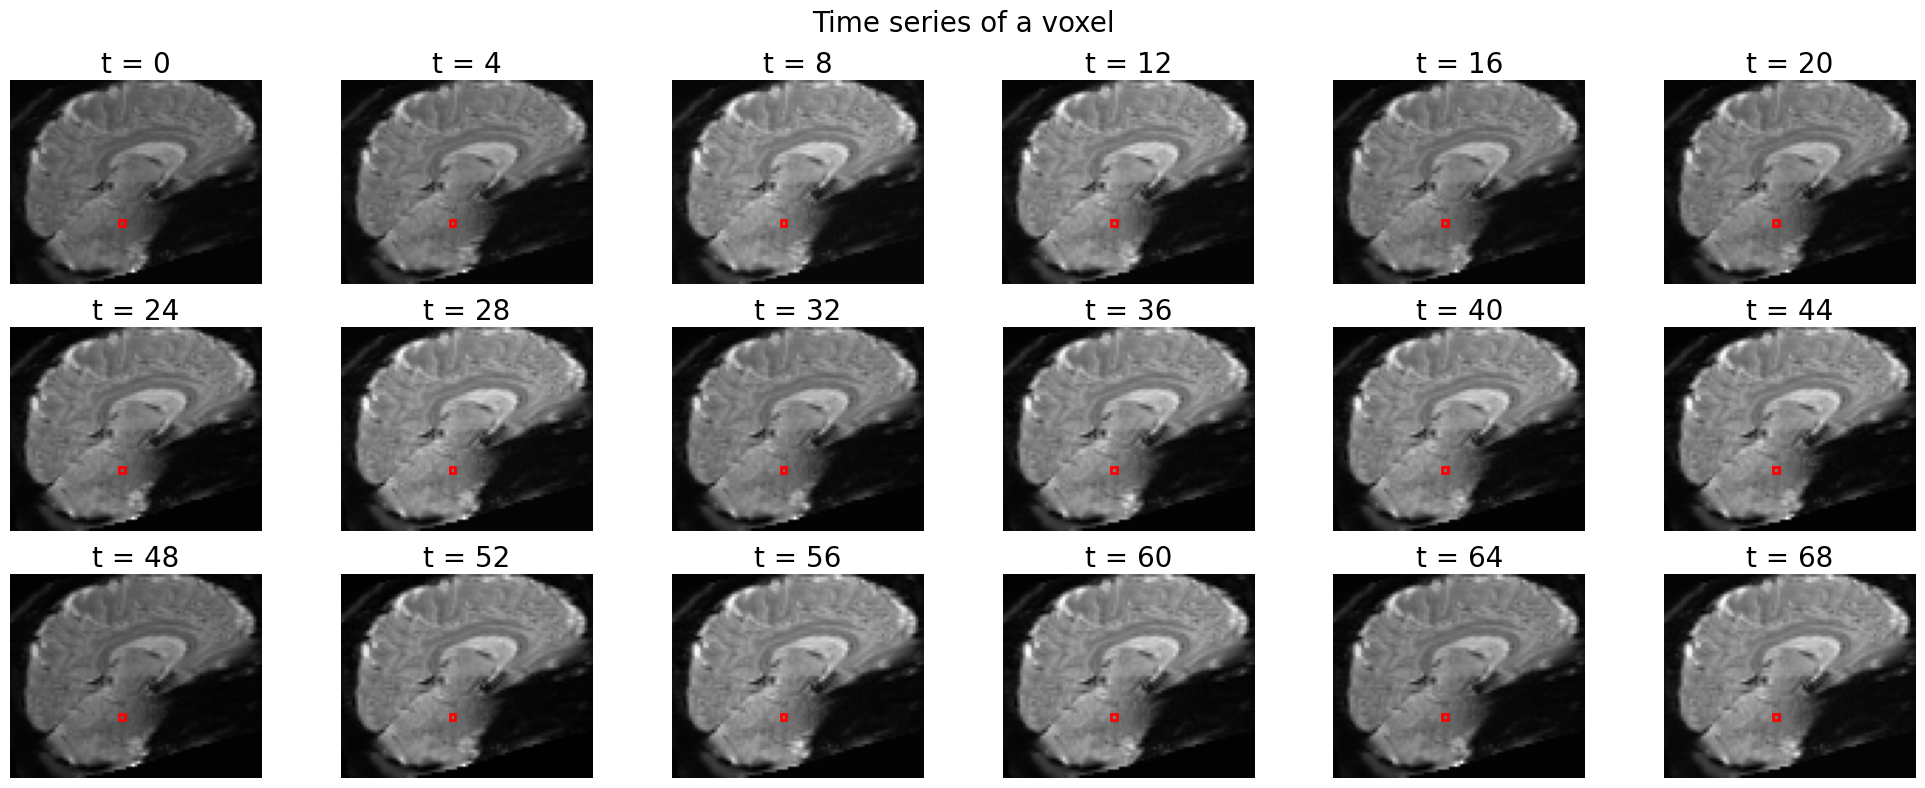

In [89]:
fig, axes = plt.subplots(ncols=6, nrows=3, figsize=(20, 8))  # 20 timepoints
# Loop over the volumes
for t, ax in enumerate(axes.flatten()):
    ax.imshow(data[39, :, :, t*4].T, cmap='gray', origin='lower')  # index with t!
    rect = Rectangle((38, 20), 2, 2, linewidth=2, edgecolor='r', facecolor='none')
    ax.add_patch(rect)
    ax.axis('off')
    ax.set_title('t = %i' % (t*4), fontsize=20)
# title of the whole figure
fig.suptitle('Time series of a voxel', fontsize=20)

fig.tight_layout()

Voxel timeseries shape: (194,)


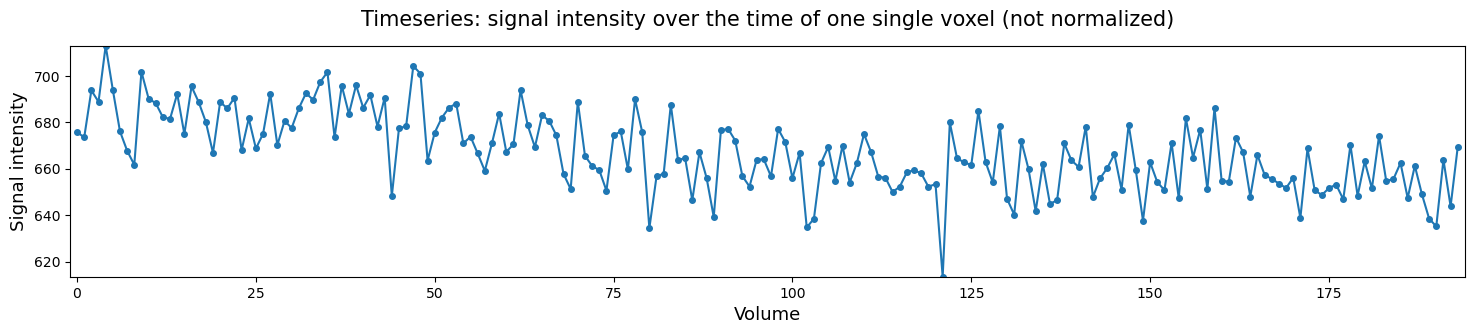

In [90]:
# take one voxel and look at its intensity over the time
mid_vox_ts = data[42, 35, 40, :]  # ":" means: give me ALL the timepoints
print("Voxel timeseries shape: %s" % (mid_vox_ts.shape,))

plt.figure(figsize=(18, 3))
plt.plot(mid_vox_ts, 'o-', ms=4)
plt.xlim(-1, mid_vox_ts.size)
plt.ylim(mid_vox_ts.min(), mid_vox_ts.max())
plt.ylabel('Signal intensity', fontsize=13)
plt.xlabel('Volume', fontsize=13)
plt.title(f'Timeseries: signal intensity over the time of one single voxel (not normalized)', fontsize=15, y=1.05)
plt.show()

# each volume is taken 2 seconds apart from the others

/tmp/ipykernel_1000/2349980089.py:3: UserWarning: Threshold given was 1e-06, but the data has no values below -72.10042572021484. 
  plotting.view_img(first_vol)
/opt/conda/envs/bigdata/lib/python3.12/site-packages/numpy/core/fromnumeric.py:771: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



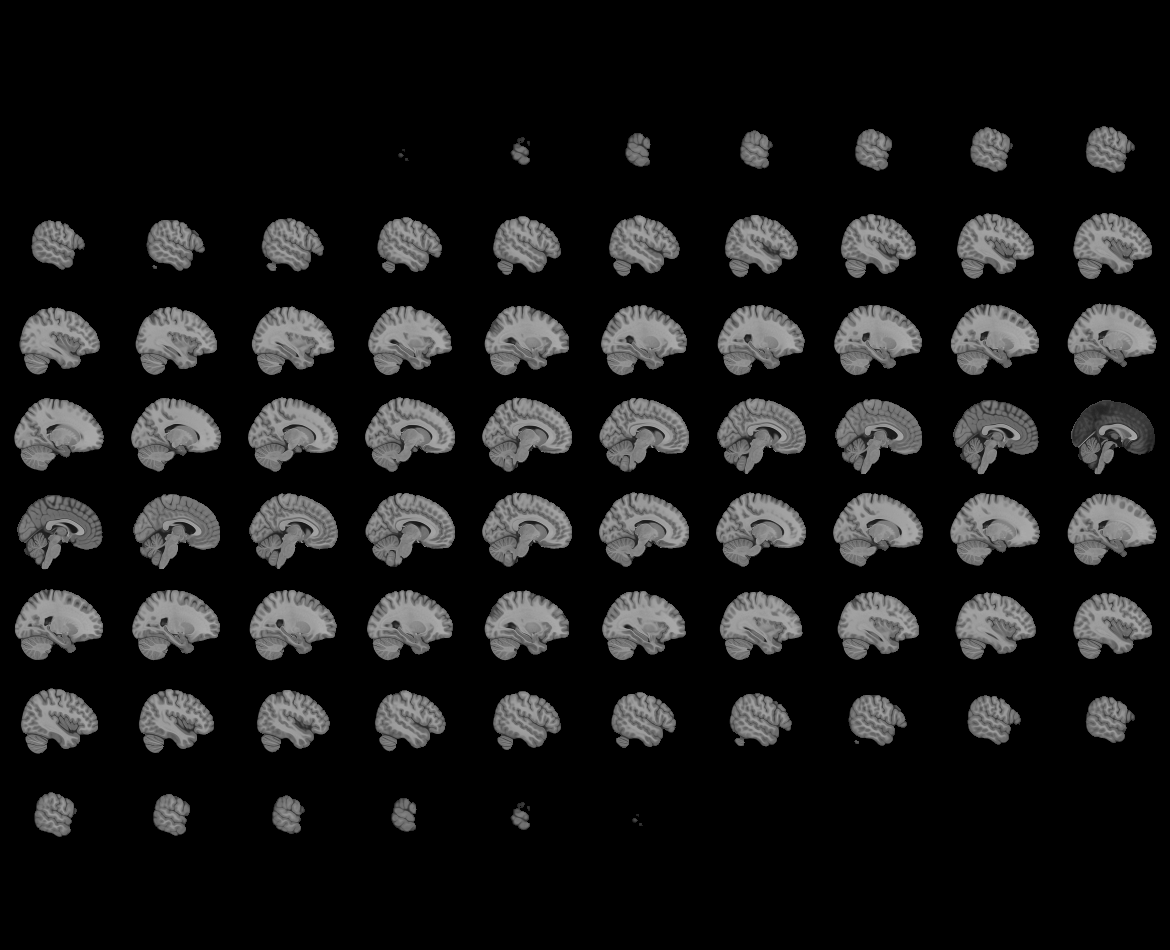
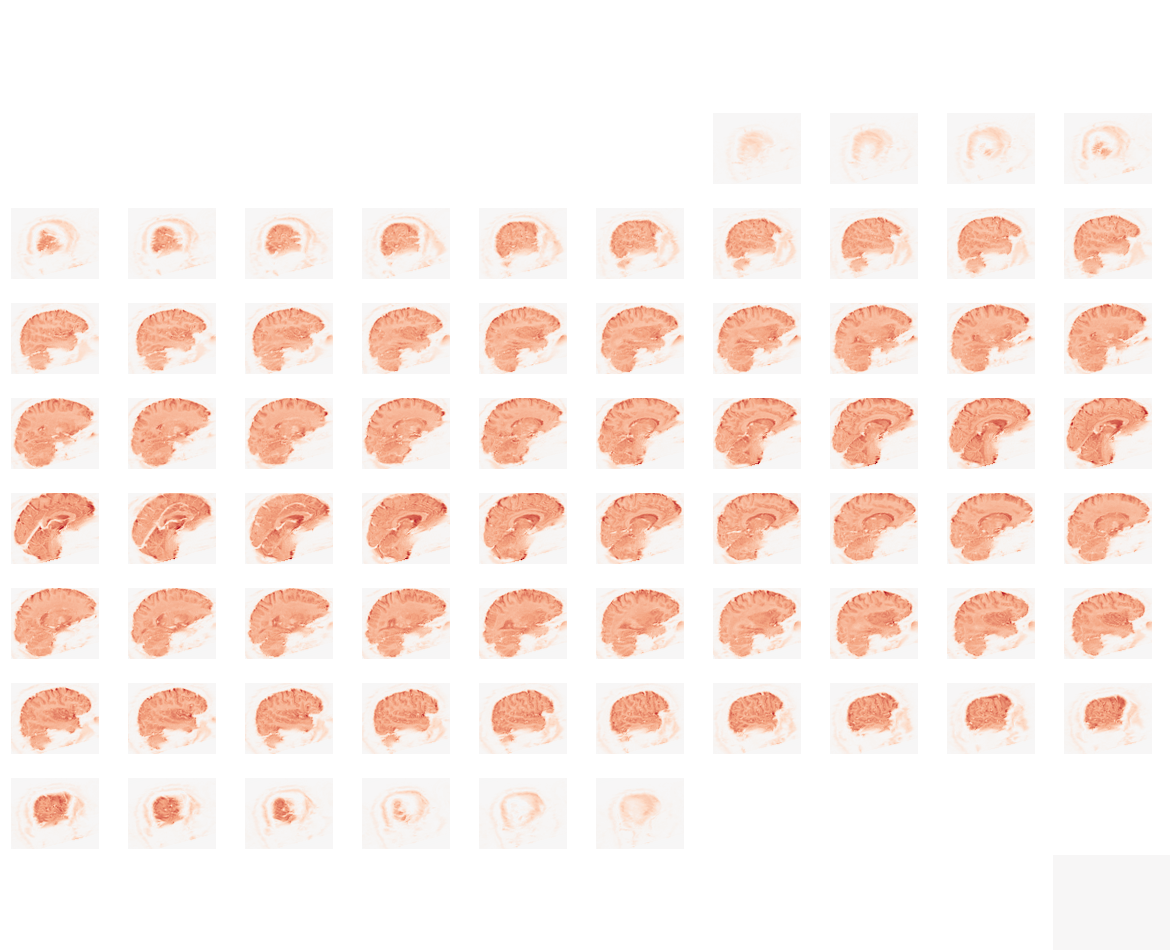

In [91]:
# Move the blue lines to see different cuts
first_vol = index_img(img, 0)
plotting.view_img(first_vol)

#### Final dataframe with the complete list of trials (stimuli presented)

In [38]:
mapping_df.head(2)

,image_name,label
0,n01930112_19568.JPEG,animal or human
1,n03733281_29214.JPEG,object


In [39]:
if not os.path.exists(os.path.join(variables.BOLD5000_PATH,'trials_df.csv')):
    # Read all the events file and extract stim_file / image (images names)
    records = []
    missing_samples = []

    # Maps the images names to the corresponding label
    mapping_dict = dict(zip(mapping_df['image_name'], mapping_df['label']))

    for idx, row in events_df.iterrows():
        ev_path = row['path']

        ev_df = pd.read_csv(ev_path, sep='\t', dtype=str)

        for _, ev in ev_df.iterrows():                     
            
            img_name = ev.get('stim_file', None)        # read the name of the stimulus presente, otherwise put None

            if 'COCO' not in img_name:

              super_label = mapping_dict.get(img_name, None)
              dataset = ev.get('ImgType', None)
              records.append({
                  'events_path': ev_path,
                  'image_name': img_name,
                  'label': super_label,
                  'dataset': dataset
              })
              if super_label is None:
                  missing_samples.append(img_name)
            else:
              continue

    # dataframe with two columns, for each stimulus presentation
    trials_df = pd.DataFrame(records)
    print("Total number of stimuli presented:", len(trials_df))

    path = os.path.join(variables.BOLD5000_PATH,'Scene_Stimuli','Presented_Stimuli')

    # for each row in trials_df, for each 'image_name', find the path for it and add it to a column trials_df['image_path]
    for idx in range(len(trials_df)):
      if trials_df['dataset'][idx] == None:
        continue
      elif 'imagenet' in trials_df['dataset'][idx]:

        trials_df.loc[idx,'image_path'] = os.path.join(path,'ImageNet',trials_df['image_name'][idx])
      elif 'coco' in trials_df['dataset'][idx]:
        trials_df.loc[idx,'image_path'] = os.path.join(path,'COCO',trials_df['image_name'][idx])
      elif 'scenes' in trials_df['dataset'][idx]:
        trials_df.loc[idx,'image_path'] = os.path.join(path,'Scene',trials_df['image_name'][idx])
      else:
        trials_df.loc[idx,'image_path'] = None

    # save
    trials_df.to_csv(os.path.join(variables.BOLD5000_PATH,'trials_df.csv'), index=False)    
else:
    trials_df = pd.read_csv(os.path.join(variables.BOLD5000_PATH,'trials_df.csv'))
trials_df.head(4)

,events_path,image_name,label,dataset,image_path
0,/tmp/ds001499/sub-CSI1/ses-01/func/sub-CSI1_se...,n01930112_19568.JPEG,animal or human,imagenet,/workspace/devcontainer-bigdata/data/Scene_Sti...
1,/tmp/ds001499/sub-CSI1/ses-01/func/sub-CSI1_se...,n03733281_29214.JPEG,object,imagenet,/workspace/devcontainer-bigdata/data/Scene_Sti...
2,/tmp/ds001499/sub-CSI1/ses-01/func/sub-CSI1_se...,n07695742_5848.JPEG,plant or food,imagenet,/workspace/devcontainer-bigdata/data/Scene_Sti...
3,/tmp/ds001499/sub-CSI1/ses-01/func/sub-CSI1_se...,n01917289_1429.JPEG,animal or human,imagenet,/workspace/devcontainer-bigdata/data/Scene_Sti...


In [40]:
trials_df.isna().sum()

events_path    0
image_name     0
label          0
dataset        0
image_path     0
dtype: int64

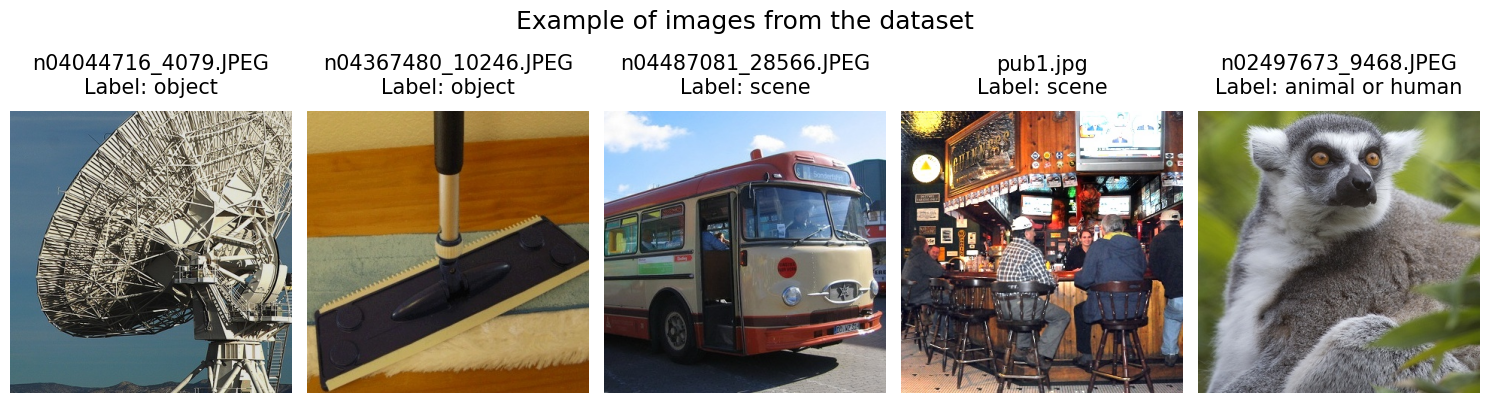

In [41]:
# Show examples of images
n_images=5
idxs = random.sample(range(0,len(trials_df)),n_images)

fig, axs = plt.subplots(1,n_images, figsize=(n_images*3, 3.9))
axes = axs.flatten()
for i in range(n_images):
    img = mpimg.imread(trials_df['image_path'][idxs[i]])
    img_name = trials_df['image_name'][idxs[i]]
    label = trials_df['label'][idxs[i]]
    axes[i].imshow(img)
    axes[i].set_title(f'{img_name}\nLabel: {label}', fontsize=15, y=1.032)
    axes[i].axis("off")
fig.suptitle("Example of images from the dataset", fontsize=18,y=1.065)
plt.tight_layout()
plt.show()

In [42]:
idxs

[10667, 1759, 3206, 3941, 4080]

In [43]:
if not os.path.exists(os.path.join(variables.BOLD5000_PATH,'trials_df.csv')):
    trials_df.to_csv(os.path.join(variables.BOLD5000_PATH,'trials_df.csv'), index=False)

#### Understand the data

For a given subject, session and run, here I plot, for each ROI, the registered signal as a function of time. (Not standardized and not detrend)

Subject CSI1, CSI2, CSI3:
- 15 functional sessions: 8 with 9 runs (+ one localizer run to identify the rois), 7 with 10 runs. 
- 1 anatomical session

Subject CSI4:
- 9 functional sessions
- 1 anatomical session
oggetti da 1 a 3: 15 ses funzionali, 1 anatomica

Each image was presented for 1 second + 9 seconds of fixation cross, during these 9 seconds the participants had to give a score about the likeability of the stimulus (like, neutral, dislike).

So, each image covers 5 TR (10 seconds).

In [106]:
mapping_df

,image_name,label
0,n01930112_19568.JPEG,animal or human
1,n03733281_29214.JPEG,object
2,n07695742_5848.JPEG,plant or food
3,n01917289_1429.JPEG,animal or human
4,n02108551_26574.JPEG,animal or human
...,...,...
11188,n02892201_13959.JPEG,scene
11189,n04192698_5041.JPEG,object
11190,n02006656_7738.JPEG,animal or human
11191,n01981276_3580.JPEG,animal or human


In [107]:
rois_df.head(3)

,subject,roi,hemisphere,filename,path,voxels_active
0,sub-CSI1,LHEarlyVis,left,sub-CSI1_mask-LHEarlyVis.nii.gz,/tmp/ds001499/derivatives/spm/sub-CSI1/sub-CSI...,210
1,sub-CSI1,LHLOC,left,sub-CSI1_mask-LHLOC.nii.gz,/tmp/ds001499/derivatives/spm/sub-CSI1/sub-CSI...,152
2,sub-CSI1,LHOPA,left,sub-CSI1_mask-LHOPA.nii.gz,/tmp/ds001499/derivatives/spm/sub-CSI1/sub-CSI...,101


In [108]:
if not os.path.exists(os.path.join(variables.BOLD5000_PATH,'rois_df.csv')):
    rois_df.to_csv(os.path.join(variables.BOLD5000_PATH,'rois_df.csv'), index=False)

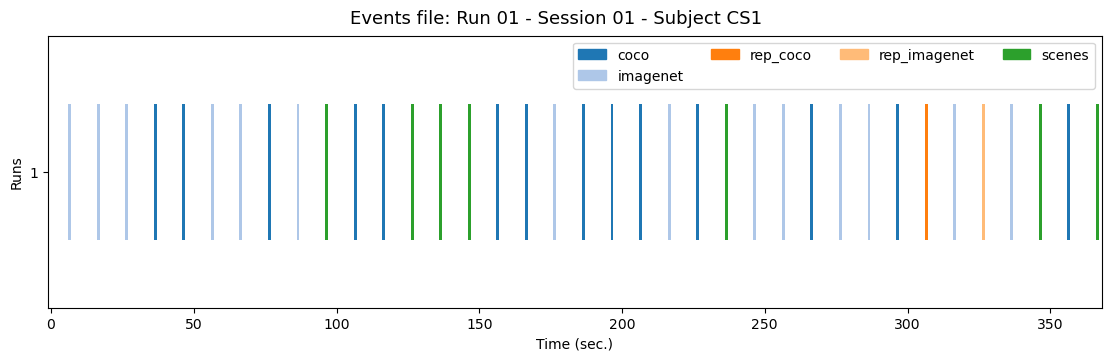

In [109]:
from nilearn.plotting import plot_event, show
# open events_df[0]
event = pd.read_csv(events_df['path'][0], sep='\t')
event['trial_type'] = event['ImgType']
fig = plot_event(event[['onset','duration','trial_type']], figsize=(11, 3.5))
fig.suptitle("Events file: Run 01 - Session 01 - Subject CS1", fontsize=13)
show()

#### Information Extraction: Extract Beta Maps trial-by-trial

Here: implement a variant of the LSS strategy - Least Squares Separate, which is a common technique to obtain a beta map for each single trial.

I build a separate GLM for each trial. In the GLM the current trial has a dedicated regressor ("target_trial"), the other are grouped in another unique regressor ("other_trials").
The contrast "target_trial" produces a beta map 3D which represents the response to that stimulus.

GLM is a mathematical model which tries to explain the BOLD signal as a combination of:
- regressors which represent the presented stimuli
- regressors which represent confounds
- a function of hemodynamic response (HRF) which models how the brain responds in time

$$
BOLD
(
𝑡
)
=
𝑋
𝛽
+
𝜖
$$

X = design matrix (stimuli + confounds)

𝛽 = weights (beta values)

𝜖 = noise

The GLM estimates 𝛽, that is how much each regressors contributes to the signal in each voxel.

In [51]:
def extract_trial_beta_features(subject: int, TR=2.0, n_scans=194):

  '''
  Args:
    subject: integer number in [1, 2, 3, 4]
    TR: time resolution of the fMRI data
    n_scans: number of TRs in the fMRI data

  Returns the features extracted, the labels, and the number of NaNs.
  It extracts the beta maps for each single trial using GLM.
  '''

  # parameters
  TR = TR
  n_scans = n_scans

  frame_times = np.arange(n_scans) * TR

  subject_nans = 0


  # Load the data (confounds, BOLD, events and rois) for one specified subject
  confounds_df_sub, functionals_df_sub, events_df_sub, rois_df_sub = functions.extract_rows_for_one_subject(subject=subject,
                                                                                                  confounds_df = confounds_df,
                                                                                                  functionals_df = functionals_df,
                                                                                                  events_df = events_df,
                                                                                                  rois_df = rois_df)


  # Lists to store the extracted features and the corresponding labels
  all_features_sub = []
  all_labels_sub = []

  # For each run
  for row in range(len(functionals_df_sub)):

    run = functionals_df_sub['run'][row]
    subj_name = functionals_df_sub['subject'][row]
    session = functionals_df_sub['session'][row]
    print(f'Subject: {str(subj_name)}, run: {run}, session: {session}')

    # Check that the run and subject correspond between different dataframes
    #assert functionals_df_sub['run'][row] == events_df_sub['run'][row] and functionals_df_sub['run'][row] == confounds_df_sub['run'][row] and events_df_sub['run'][row] == confounds_df_sub['run'][row]
    assert functionals_df_sub['subject'][row] == events_df_sub['subject'][row] and functionals_df_sub['subject'][row] == confounds_df_sub['subject'][row] and events_df_sub['subject'][row] == confounds_df_sub['subject'][row]

    # Load data
    func_img = nib.load(functionals_df_sub['path'][row])
    confound = pd.read_csv(confounds_df_sub['path'][row], sep='\t')
    event = pd.read_csv(events_df_sub['path'][row], sep='\t')

    # Use trials_df to map the image names to the label
    event['trial_type'] = event['ImgName'].map(
      trials_df.drop_duplicates(subset=['image_name'])
      .set_index('image_name')['label']
    )

    # Check if there are duplicates
    duplicates = event.duplicated(subset=['onset','duration','trial_type'], keep=False)
    if duplicates.any():
        print("There are duplicates in this run:")
        display(event[duplicates])

    # Check that the number of volumes is 194
    assert func_img.shape[-1] == n_scans and confound.shape[0] == n_scans 
  
    # Interpolate confound to avoid NaNs values in the first
    confound = confound.interpolate(method='linear', limit_direction='both')
    # give error if there are still NaNs
    assert not confound.isna().any().any()    # assert that confound.isna().any().any() == False


    rois_list_sub = [rois_df_sub['path'][i] for i in range(len(rois_df_sub))]

    # Check alignment between functional image and each ROI
    if False:
      print("Functional affine:\n", func_img.affine)

      for roi in rois_list_sub:
          roi_affine = nib.load(roi).affine
          print(f"\nROI: {roi}")
          print("ROI affine:\n", roi_affine)


    # Create a masker for each roi, without initial standardization
    maskers = [NiftiMasker(mask_img=roi,
                          standardize=False,
                          detrend=False)
                          for roi in rois_list_sub]
    # For each ROI (file NIfTI, a mask) creates a NiftiMasker object which will be used
    # to transform the beta maps in voxel-wise vectors

    # A Beta map is a 3D image which contains, for each voxel of the brain, its activation value
    # which is given by the GLM for a certain trial.

    # The NiftiMasker is a tool which takes a mask (ROI) and uses it as a filter, selecting
    # only the voxels inside that area, and transform them in a vector of numbers. 
    # One numeric value for each voxel of the ROI.

    # In this strategy (LSS - Least Squares Separate) I am building a 3D beta map for each trial.
    # It represents a 3D image of the brain in which each voxel has a value
    # which represents the amplitude of the estimated responde to that stimulus (trial)

    # Then, the maskers transform them in vectors, for the classificaztion task.

    # fit the maskers
    for masker in maskers:
      masker.fit()

    # transform functional data with maskers
    # roi_timeseries = [masker.transform(func_img) for masker in maskers]

    # extract features for each trial
    run_features = []
    run_labels = []

    number_nans = 0

    # Loop on the trials
    for idx, trial in event.iterrows():
      if pd.isna(trial['trial_type']):
        number_nans += 1
        continue

      if 'coco' in trial['ImgType']:
        print(f'Trial {idx}: COCO')
        continue

      # Create design matrix for this trial
      # the design matrix has a target regressor (current trial) and a regressor 'other_trials'
      trial_events = pd.DataFrame({
          'onset': [trial['onset']],
          'duration': [trial['duration']],
          'trial_type': ['target_trial']
      })


      # add other trials as regressor
      other_trials = event[event.index != idx].copy()
      if len(other_trials) > 0:
        other_trials['trial_type'] = 'other_trials'
        combined_events  = pd.concat([trial_events, other_trials], ignore_index=True)
      else:
        combined_events = trial_events

      # Fit a GLM
      try:
        glm = FirstLevelModel(
            t_r = TR,
            standardize = False,      #False
            hrf_model = 'spm',
            drift_model = 'cosine',
            minimize_memory = False,
            signal_scaling = False
        )

        glm.fit(func_img, combined_events[['onset', 'duration', 'trial_type']], confound)

        # Calculate the contrast for the target regressor
        # Obtain beta map for the target trial
        beta_map = glm.compute_contrast('target_trial', output_type='effect_size')
        # beta_map has same dimension of bold data (without 4th dimension). Ex (71, 89, 72))

        print(f'Beta map type: {type(beta_map)}, shape: {beta_map.shape},  trial: {idx}')

        # Apply the maskers ROI to the beta map 
        # --> Obtain a vector of voxels value for each ROI
        trial_features = []
        for i, masker in enumerate(maskers):
          roi_betas = masker.transform(beta_map)    # (1, n_voxels_in_roi)
          # print(f'    Masker number: {i},  shape roi_betas: {roi_betas.shape}')

          roi_betas = np.asarray(roi_betas)
          roi_betas = np.atleast_2d(np.ravel(roi_betas))  
          # roi betas is a matrix (1,n_voxels_in_roi) -> one row and many columns
          # print(f'    roi_betas new shape: {roi_betas.shape}')

          # print(f'roi_betas[0].shape: ', roi_betas[0].shape, '   roi_betas[:5]...: ', roi_betas[:5])
          # roi_betas[0] takes the first and only row
          trial_features.extend(roi_betas[0].tolist())
          # print(f'    trial_features: {len(trial_features)}, trial_features[0]: {trial_features[0]}')

        # Concatenating the rois vectors, I obtain the feature for this trial
        run_features.append(trial_features)
        run_labels.append(trial['trial_type'])  # Save also the corresponding label

        # if idx%5==0:
          # print(f" --- Trial {idx}/{len(event)} completed.\n")

      except Exception as e:
        print(f"Error in computing the contrast for {trial['trial_type']}  - trial index: {idx}: {e}\n")
        continue


    # add to list
    all_features_sub.append(run_features)
    all_labels_sub.append(run_labels)

    # all_features_sub should have length = number of runs
    # Number of NaNa is the number of trials without label
    print(f'Number of NaNs in run {run} sub: {subj_name} ses: {session}  -->  {number_nans}\n')

    subject_nans+=number_nans

  return all_features_sub, all_labels_sub, subject_nans

In [52]:
f, l, n = extract_trial_beta_features(subject=3)

Subject: sub-CSI3, run: 1, session: ses-01
Beta map type: <class 'nibabel.nifti1.Nifti1Image'>, shape: (72, 88, 67),  trial: 5
Beta map type: <class 'nibabel.nifti1.Nifti1Image'>, shape: (72, 88, 67),  trial: 6
Beta map type: <class 'nibabel.nifti1.Nifti1Image'>, shape: (72, 88, 67),  trial: 7
Beta map type: <class 'nibabel.nifti1.Nifti1Image'>, shape: (72, 88, 67),  trial: 8
Beta map type: <class 'nibabel.nifti1.Nifti1Image'>, shape: (72, 88, 67),  trial: 9
Beta map type: <class 'nibabel.nifti1.Nifti1Image'>, shape: (72, 88, 67),  trial: 10
Beta map type: <class 'nibabel.nifti1.Nifti1Image'>, shape: (72, 88, 67),  trial: 11
Beta map type: <class 'nibabel.nifti1.Nifti1Image'>, shape: (72, 88, 67),  trial: 13
Beta map type: <class 'nibabel.nifti1.Nifti1Image'>, shape: (72, 88, 67),  trial: 14
Beta map type: <class 'nibabel.nifti1.Nifti1Image'>, shape: (72, 88, 67),  trial: 15
Beta map type: <class 'nibabel.nifti1.Nifti1Image'>, shape: (72, 88, 67),  trial: 16
Beta map type: <class 'niba

In [53]:
%cd /workspace/devcontainer-bigdata/data

/workspace/devcontainer-bigdata/data


In [54]:
# Save in pickle format
with open("subject3_features.pkl", "wb") as fp:
    pickle.dump({"features": f, "labels": l, "n_nans": n}, fp)

print("Salvato subject3_features.pkl")

Salvato subject3_features.pkl


In [141]:
print(f'Type f: {type(f)} - Len: {len(f)}')
print(f'Type f[0]: {type(f[0])} - Len: {len(f[0])}')
print(f'Type f[0][0]: {type(f[0][0])} - Len: {len(f[0][0])}')
print(f'Type f[0][1]: {type(f[0][1])} - Len: {len(f[0][1])}')
print(f'Type f[1][0]: {type(f[0][1])} - Len: {len(f[1][0])}')

# I have extracted info for the first 5 rows of functionals_df (for the first 5 runs). So len(f) == 5
# f[0] refers to the first run, which has 22 good trials (excluding 15 COCO stimuli)
# f[0][0] refers to the first trial of run 01, which has len 1685 (that is the number of active voxels of ALL the rois)

# For subject 2, the dimensions will change

Type f: <class 'list'> - Len: 84
Type f[0]: <class 'list'> - Len: 21
Type f[0][0]: <class 'list'> - Len: 2787
Type f[0][1]: <class 'list'> - Len: 2787
Type f[1][0]: <class 'list'> - Len: 2787


In [229]:
print(f'Type l: {type(l)} - Len: {len(l)}')
print(f'Type l[0]: {type(l[0])} - len: {len(l[0])}')
print(f'Type l[0][0]: {type(l[0][0])} - l[0][0]: {l[0][0]}')

Type l: <class 'list'> - Len: 5
Type l[0]: <class 'list'> - len: 22
Type l[0][0]: <class 'str'> - l[0][0]: animal


In [223]:
for sub in range(1,5):
  subject = f'sub-CSI{sub}'
  sub_voxels=0
  for row in range(len(rois_df)):
    if rois_df['subject'][row]==subject:
        sub_voxels+=rois_df['voxels_active'][row]
  print(f'Subject {subject}: number of total voxels across the rois: {sub_voxels}')

Subject sub-CSI1: number of total voxels across the rois: 1685
Subject sub-CSI2: number of total voxels across the rois: 1851
Subject sub-CSI3: number of total voxels across the rois: 2581
Subject sub-CSI4: number of total voxels across the rois: 2787


In [ ]:
# Load 
with open("/workspace/devcontainer-bigdata/data/subject1_features.pkl", "rb") as fp:
    data = pickle.load(fp)

#Extract the parts
f = data["features"]
l = data["labels"]
n = data["n_nans"]

print("Number of runs:", len(f))
print("Number of labels in the first run:", len(l[0]))
print("Number of NaNs:", n)

Numero di runs: 142
Numero di labels nel primo run: 22
Numero di NaNs: 2135
